In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect('/content/grab_vn_case.db')

In [3]:
cur = conn.cursor()
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cur.fetchall())

[('users',), ('weather_daily',), ('transactions',)]


In [5]:
users_df = pd.read_sql_query("SELECT * from users", conn)
transaction_df = pd.read_sql_query("SELECT * from transactions", conn)
sum_df = pd.read_sql_query("SELECT * from daily_gmv_summary", conn)
weather_df = pd.read_sql_query("SELECT * from weather_daily", conn)

print("users_df.columns:")
for col in users_df.columns:
    print(col)

print("\ntransaction_df.columns:")
for col in transaction_df.columns:
    print(col)

print("\nsum_df.columns:")
for col in sum_df.columns:
    print(col)

print("\nweather_df.columns:")
for col in weather_df.columns:
    print(col)

users_df.columns:
user_id
city
payment_preference
user_segment
registration_date

transaction_df.columns:
transaction_id
date
week_number
period
city
service_type
user_id
payment_type
gross_gmv_k_vnd
discount_k_vnd
net_gmv_k_vnd
voucher_applied
rainfall_mm

sum_df.columns:
date
week_number
period
city
service_type
payment_type
net_gmv_k_vnd
gross_gmv_k_vnd
total_discount_k_vnd
n_transactions
n_voucher_redemptions

weather_df.columns:
date
city
rainfall_mm
rain_category


In [13]:
total_users = users_df['user_id'].nunique()
total_vouchers_distributed = sum_df['n_voucher_redemptions'].sum()
total_gmv = transaction_df['gross_gmv_k_vnd'].sum()
total_transactions = transaction_df['transaction_id'].count()
net_gmv = transaction_df['net_gmv_k_vnd'].sum()

print(f"Overall Business Performance:")
print(f"Total Users: {total_users}")
print(f"Total Vouchers Distributed: {total_vouchers_distributed}")
print(f"Total GMV (k VND): {total_gmv:.2f}")
print(f"Total Transactions: {total_transactions}")
print(f"Net GMV (k VND): {net_gmv:.2f}")

Overall Business Performance:
Total Users: 11800
Total Vouchers Distributed: 35015
Total GMV (k VND): 21992457.86
Total Transactions: 182313
Net GMV (k VND): 20819505.22


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for Ho Chi Minh City
hcmc_transactions = transaction_df[transaction_df['city'] == 'Ho Chi Minh City'].copy()

# Convert date column to datetime objects
hcmc_transactions['date'] = pd.to_datetime(hcmc_transactions['date'])

# Aggregate GMV and transactions by date and period
hcmc_daily_performance = hcmc_transactions.groupby(['date', 'period']).agg(
    total_gmv=('gross_gmv_k_vnd', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()

These plots show the daily GMV and number of transactions in Ho Chi Minh City, segmented by 'Pre-Promo' and 'Promo' periods. This visualization will help us understand the impact of the voucher launch on these key metrics.

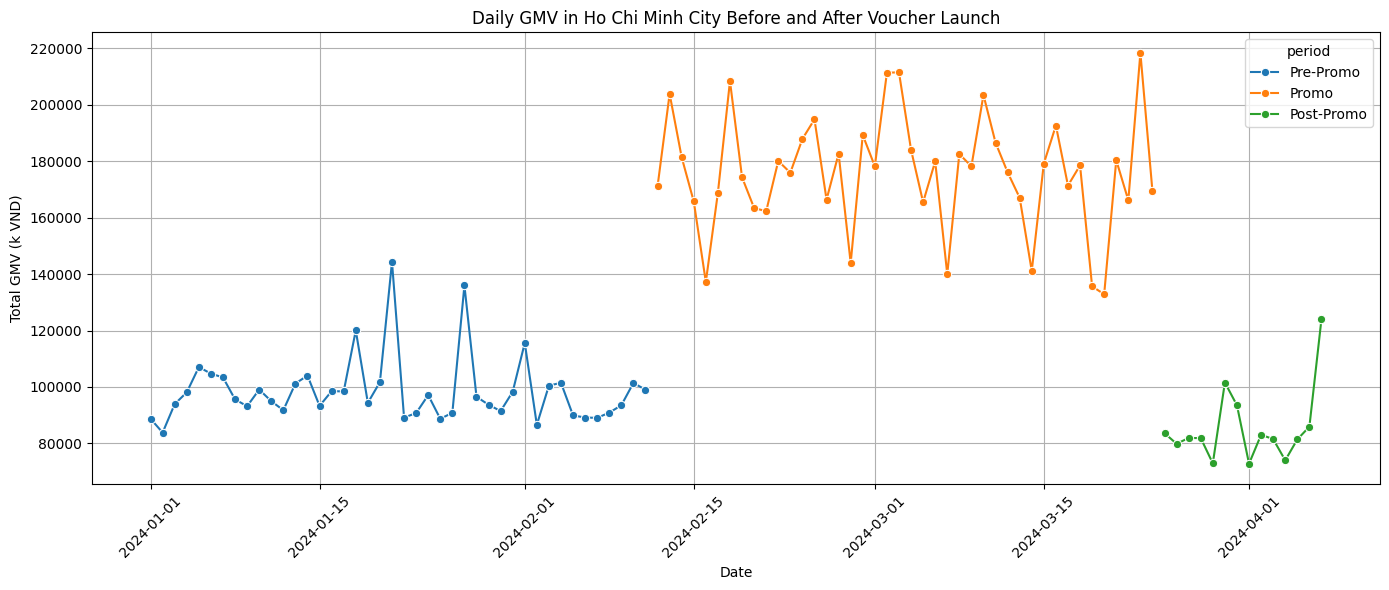

In [15]:
# Plotting GMV over time
fig1 = plt.figure(figsize=(14, 6))
sns.lineplot(data=hcmc_daily_performance, x='date', y='total_gmv', hue='period', marker='o')
plt.title('Daily GMV in Ho Chi Minh City Before and After Voucher Launch')
plt.xlabel('Date')
plt.ylabel('Total GMV (k VND)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

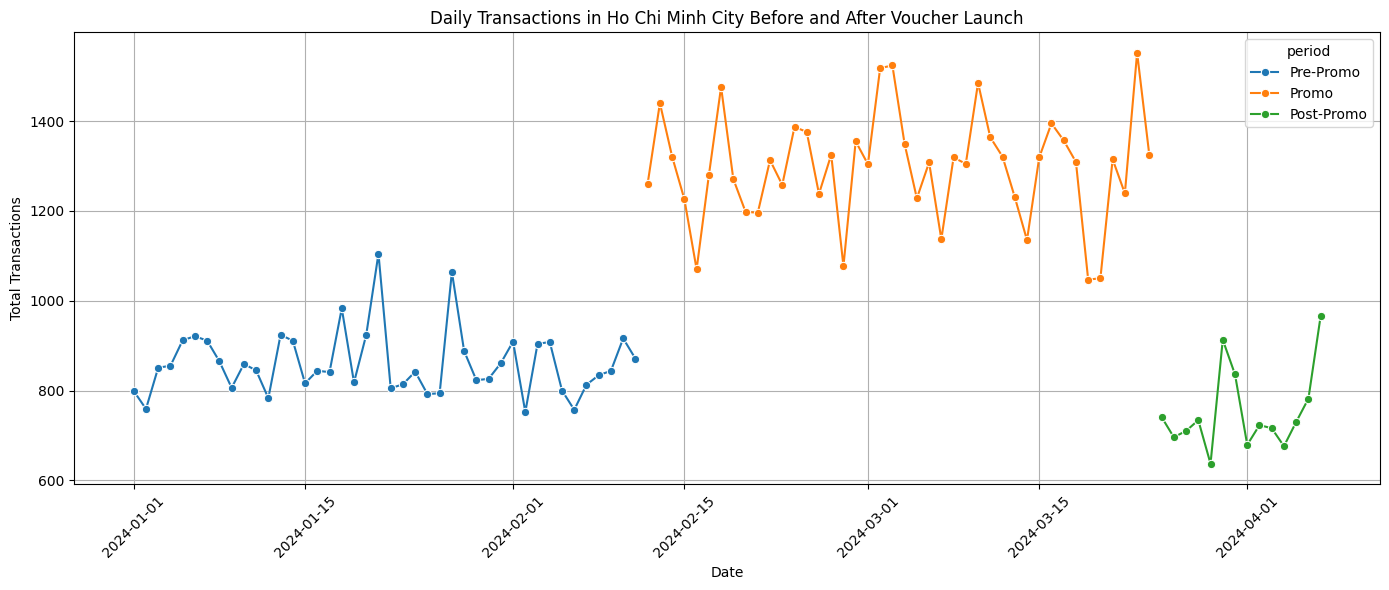

In [16]:
# Plotting Transactions over time
fig2 = plt.figure(figsize=(14, 6))
sns.lineplot(data=hcmc_daily_performance, x='date', y='total_transactions', hue='period', marker='o')
plt.title('Daily Transactions in Ho Chi Minh City Before and After Voucher Launch')
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for Ho Chi Minh City and Hanoi
cities_transactions = transaction_df[transaction_df['city'].isin(['Ho Chi Minh City', 'Hanoi'])].copy()

# Convert date column to datetime objects
cities_transactions['date'] = pd.to_datetime(cities_transactions['date'])

# Aggregate GMV and transactions by date, city, and service type
cities_daily_service_performance = cities_transactions.groupby(['date', 'city', 'service_type']).agg(
    total_gmv=('gross_gmv_k_vnd', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()

These plots illustrate the daily GMV and number of transactions, segmented by service type, for both Ho Chi Minh City and Hanoi. This will help us understand the performance of different service types in each city over time.

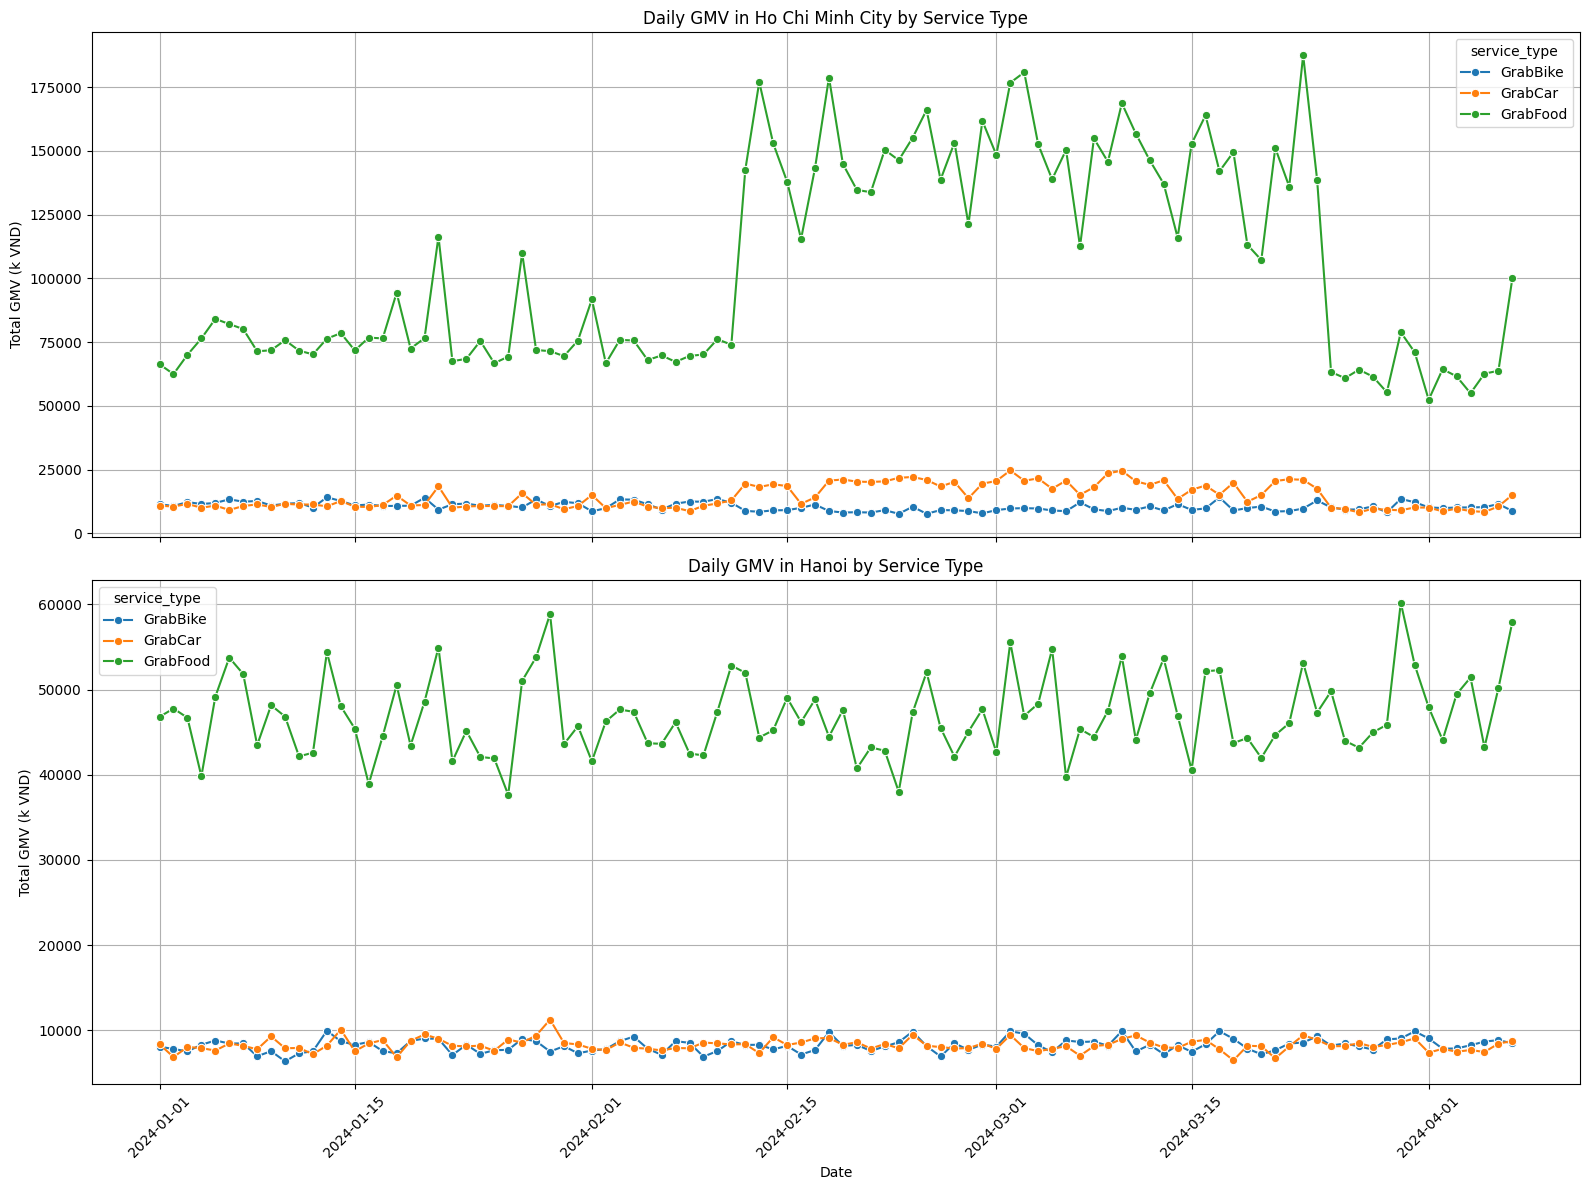

In [18]:
# Plotting GMV over time for each city and service type
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 12), sharex=True)

sns.lineplot(data=cities_daily_service_performance[cities_daily_service_performance['city'] == 'Ho Chi Minh City'],
             x='date', y='total_gmv', hue='service_type', marker='o', ax=axes[0])
axes[0].set_title('Daily GMV in Ho Chi Minh City by Service Type')
axes[0].set_ylabel('Total GMV (k VND)')
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=cities_daily_service_performance[cities_daily_service_performance['city'] == 'Hanoi'],
             x='date', y='total_gmv', hue='service_type', marker='o', ax=axes[1])
axes[1].set_title('Daily GMV in Hanoi by Service Type')
axes[1].set_ylabel('Total GMV (k VND)')
axes[1].set_xlabel('Date')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

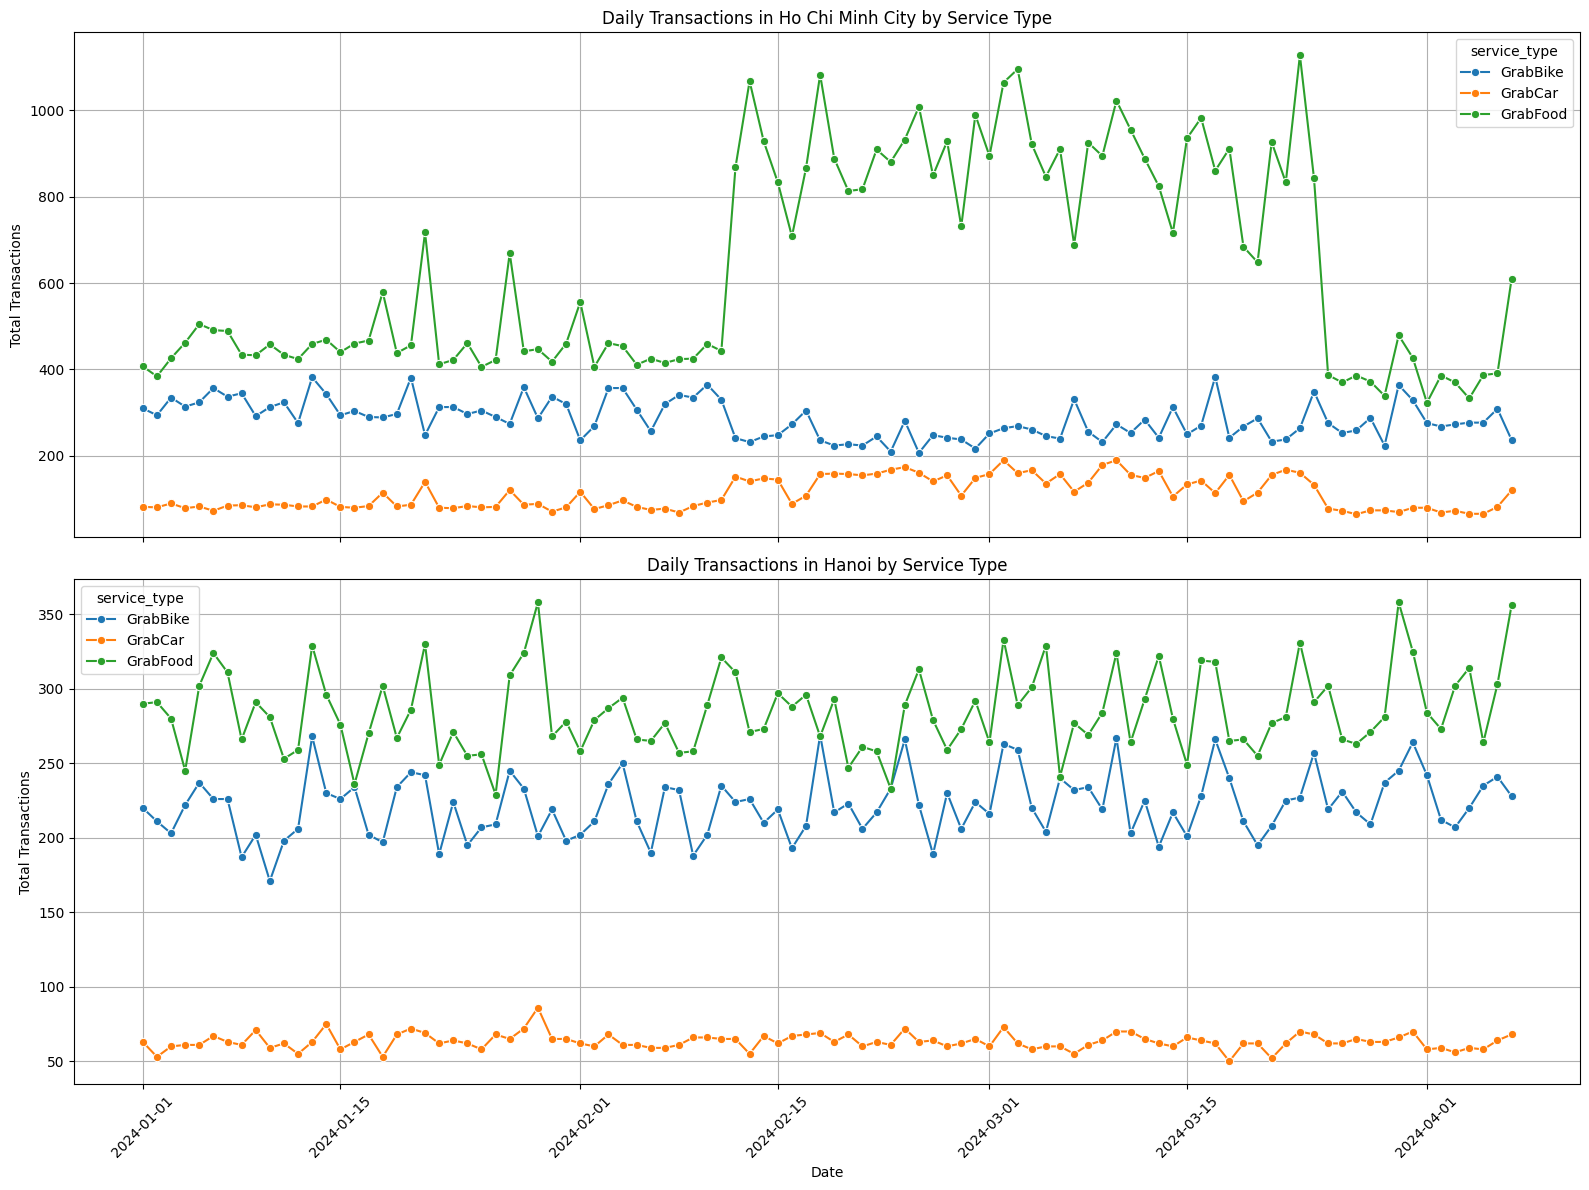

In [19]:
# Plotting Transactions over time for each city and service type
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 12), sharex=True)

sns.lineplot(data=cities_daily_service_performance[cities_daily_service_performance['city'] == 'Ho Chi Minh City'],
             x='date', y='total_transactions', hue='service_type', marker='o', ax=axes[0])
axes[0].set_title('Daily Transactions in Ho Chi Minh City by Service Type')
axes[0].set_ylabel('Total Transactions')
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=cities_daily_service_performance[cities_daily_service_performance['city'] == 'Hanoi'],
             x='date', y='total_transactions', hue='service_type', marker='o', ax=axes[1])
axes[1].set_title('Daily Transactions in Hanoi by Service Type')
axes[1].set_ylabel('Total Transactions')
axes[1].set_xlabel('Date')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# Merge users_df and transaction_df on user_id
merged_df = pd.merge(transaction_df, users_df, on='user_id', how='left')

# Filter for Ho Chi Minh City
hcmc_merged_df = merged_df[merged_df['city_x'] == 'Ho Chi Minh City'].copy()

# Count unique users per segment before and after the promo
customer_growth_by_segment = hcmc_merged_df.groupby(['user_segment', 'period'])['user_id'].nunique().reset_index()
customer_growth_by_segment.rename(columns={'user_id': 'unique_customers'}, inplace=True)

This visualization shows the number of unique customers in each segment ('New User', 'Regular', 'Voucher Hunter', 'High Value') during the 'Pre-Promo', 'Promo' and 'Post-Promo' periods in Ho Chi Minh City. This will help us identify which segments experienced growth or decline after the voucher program was launched.

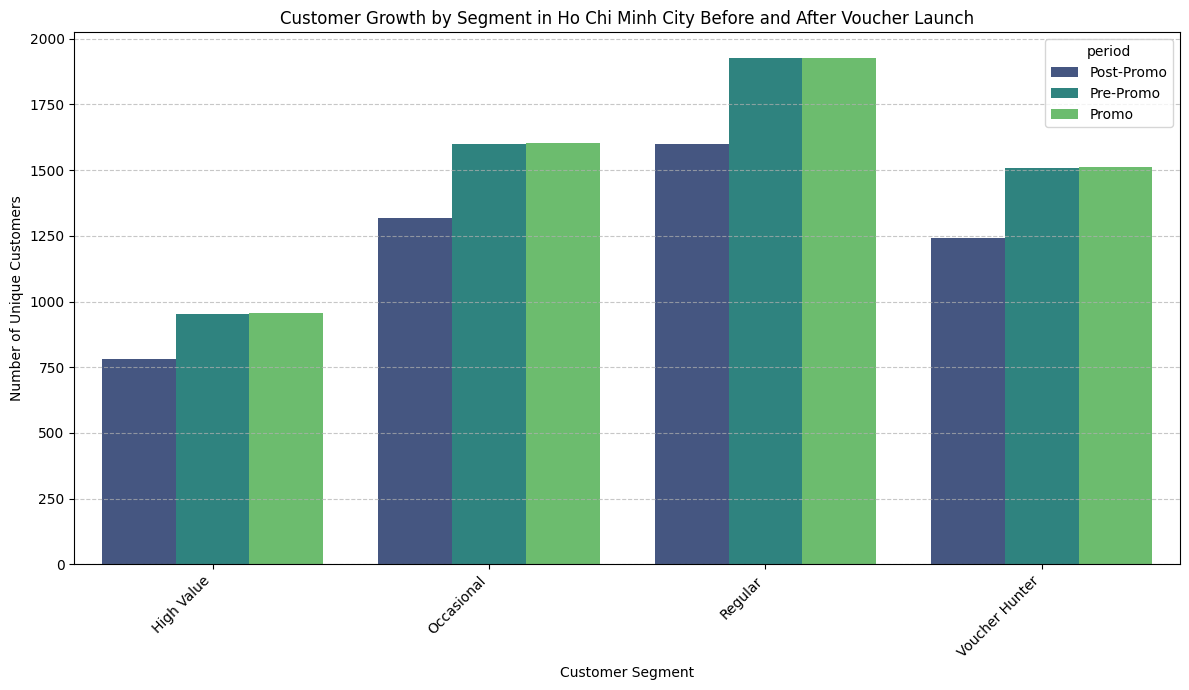

In [21]:
# Visualize the customer growth by segment
fig = plt.figure(figsize=(12, 7))
sns.barplot(data=customer_growth_by_segment, x='user_segment', y='unique_customers', hue='period', palette='viridis')
plt.title('Customer Growth by Segment in Ho Chi Minh City Before and After Voucher Launch')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Unique Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Customer Segment Share in Ho Chi Minh City and Hanoi

In [25]:
segment_share = merged_df.groupby(['city_x', 'user_segment'])['user_id'].nunique().reset_index()
segment_share.rename(columns={'city_x': 'city', 'user_id': 'total_users'}, inplace=True)

# Filter for Ho Chi Minh City and Hanoi
cities_segment_share = segment_share[segment_share['city'].isin(['Ho Chi Minh City', 'Hanoi'])]

# Find the largest segment for each city
largest_segment_hcmc = cities_segment_share[cities_segment_share['city'] == 'Ho Chi Minh City'].loc[cities_segment_share[cities_segment_share['city'] == 'Ho Chi Minh City']['total_users'].idxmax()]
largest_segment_hanoi = cities_segment_share[cities_segment_share['city'] == 'Hanoi'].loc[cities_segment_share[cities_segment_share['city'] == 'Hanoi']['total_users'].idxmax()]

print(f"Largest segment in Ho Chi Minh City: {largest_segment_hcmc['user_segment']} with {largest_segment_hcmc['total_users']} users")
print(f"Largest segment in Hanoi: {largest_segment_hanoi['user_segment']} with {largest_segment_hanoi['total_users']} users")

display(cities_segment_share)

Largest segment in Ho Chi Minh City: Regular with 1929 users
Largest segment in Hanoi: Regular with 1333 users


,city,user_segment,total_users
4,Hanoi,High Value,800
5,Hanoi,Occasional,967
6,Hanoi,Regular,1333
7,Hanoi,Voucher Hunter,900
8,Ho Chi Minh City,High Value,955
9,Ho Chi Minh City,Occasional,1603
10,Ho Chi Minh City,Regular,1929
11,Ho Chi Minh City,Voucher Hunter,1513


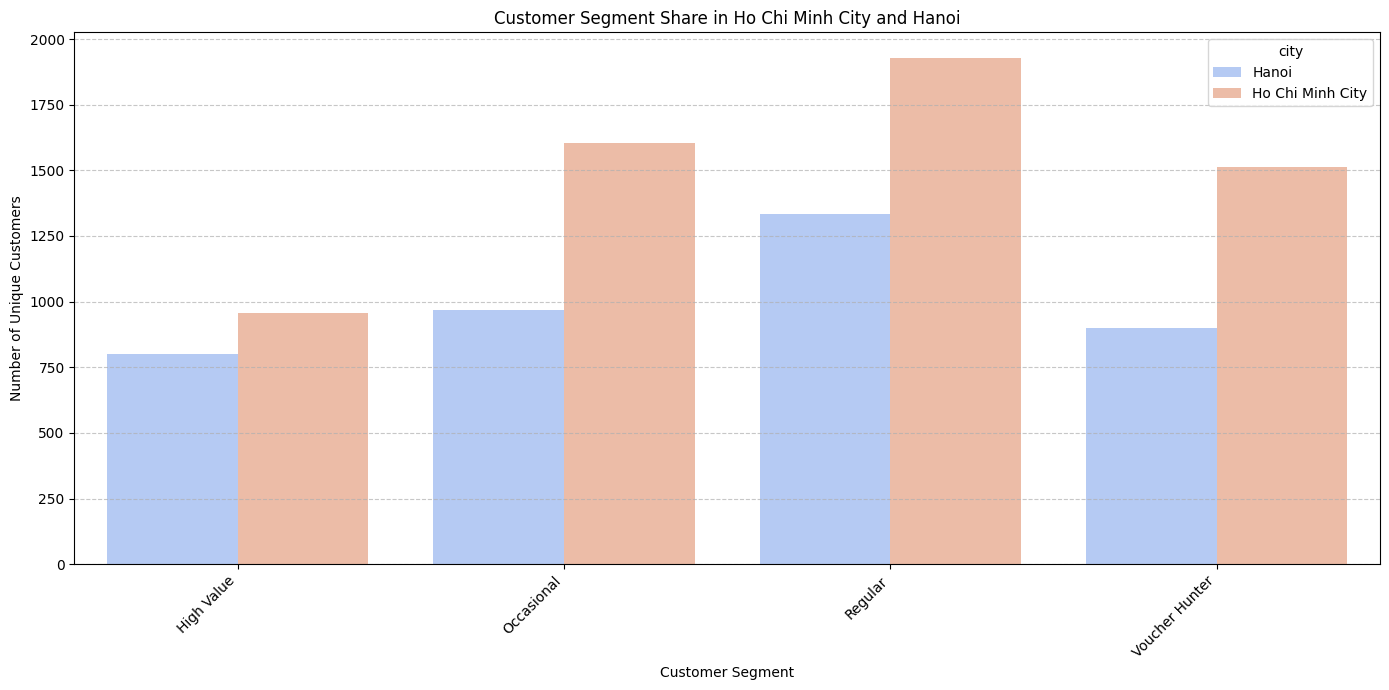

In [26]:
fig = plt.figure(figsize=(14, 7))
sns.barplot(data=cities_segment_share, x='user_segment', y='total_users', hue='city', palette='coolwarm')
plt.title('Customer Segment Share in Ho Chi Minh City and Hanoi')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Unique Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top Service Types in Ho Chi Minh City and Hanoi

In [27]:
# Aggregate GMV and transactions by city and service type
service_type_performance = cities_daily_service_performance.groupby(['city', 'service_type']).agg(
    total_gmv=('total_gmv', 'sum'),
    total_transactions=('total_transactions', 'sum')
).reset_index()

# Display the top service types by total GMV for each city
print("Top Service Types by Total GMV:")
for city in service_type_performance['city'].unique():
    city_df = service_type_performance[service_type_performance['city'] == city]
    top_service = city_df.loc[city_df['total_gmv'].idxmax()]
    print(f"  {city}: {top_service['service_type']} (GMV: {top_service['total_gmv']:.2f} k VND)")

display(service_type_performance)

Top Service Types by Total GMV:
  Hanoi: GrabFood (GMV: 4597194.68 k VND)
  Ho Chi Minh City: GrabFood (GMV: 10273505.26 k VND)


,city,service_type,total_gmv,total_transactions
0,Hanoi,GrabBike,805081.11,21737
1,Hanoi,GrabCar,807409.70,6205
2,Hanoi,GrabFood,4597194.68,27918
3,Ho Chi Minh City,GrabBike,1035257.30,27971
4,Ho Chi Minh City,GrabCar,1415716.39,10903
5,Ho Chi Minh City,GrabFood,10273505.26,62316


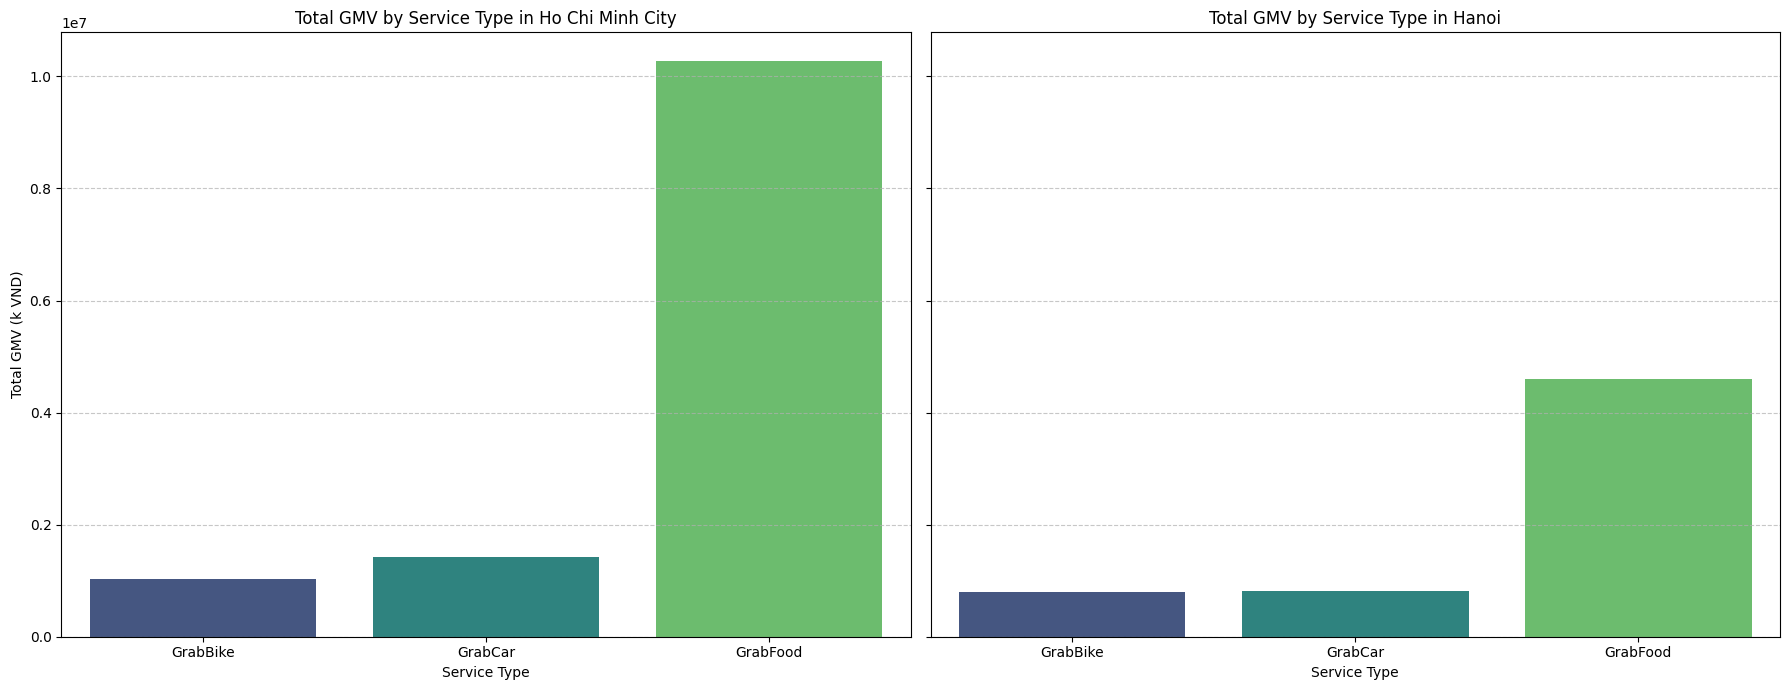

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7), sharey=True)

sns.barplot(data=service_type_performance[service_type_performance['city'] == 'Ho Chi Minh City'],
            x='service_type', y='total_gmv', ax=axes[0], palette='viridis', hue='service_type', legend=False)
axes[0].set_title('Total GMV by Service Type in Ho Chi Minh City')
axes[0].set_ylabel('Total GMV (k VND)')
axes[0].set_xlabel('Service Type')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(data=service_type_performance[service_type_performance['city'] == 'Hanoi'],
            x='service_type', y='total_gmv', ax=axes[1], palette='viridis', hue='service_type', legend=False)
axes[1].set_title('Total GMV by Service Type in Hanoi')
axes[1].set_ylabel('Total GMV (k VND)')
axes[1].set_xlabel('Service Type')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [22]:
# Merge transaction and weather data
merged_weather_transactions = pd.merge(transaction_df, weather_df, on=['date', 'city'], how='left')

# Filter for Ho Chi Minh City and Hanoi
cities_weather_data = merged_weather_transactions[merged_weather_transactions['city'].isin(['Ho Chi Minh City', 'Hanoi'])].copy()

# Aggregate GMV and transactions by city and rain category
rain_impact = cities_weather_data.groupby(['city', 'rain_category']).agg(
    avg_gmv=('gross_gmv_k_vnd', 'mean'),
    total_transactions=('transaction_id', 'count')
).reset_index()

# Fill None rain_category with 'No Rain' for better visualization
rain_impact['rain_category'] = rain_impact['rain_category'].fillna('No Rain')

These plots show the average GMV and total transactions aggregated by rain category for Ho Chi Minh City and Hanoi. This will help us visually identify any patterns or correlations between rainfall and consumer behavior in these cities.

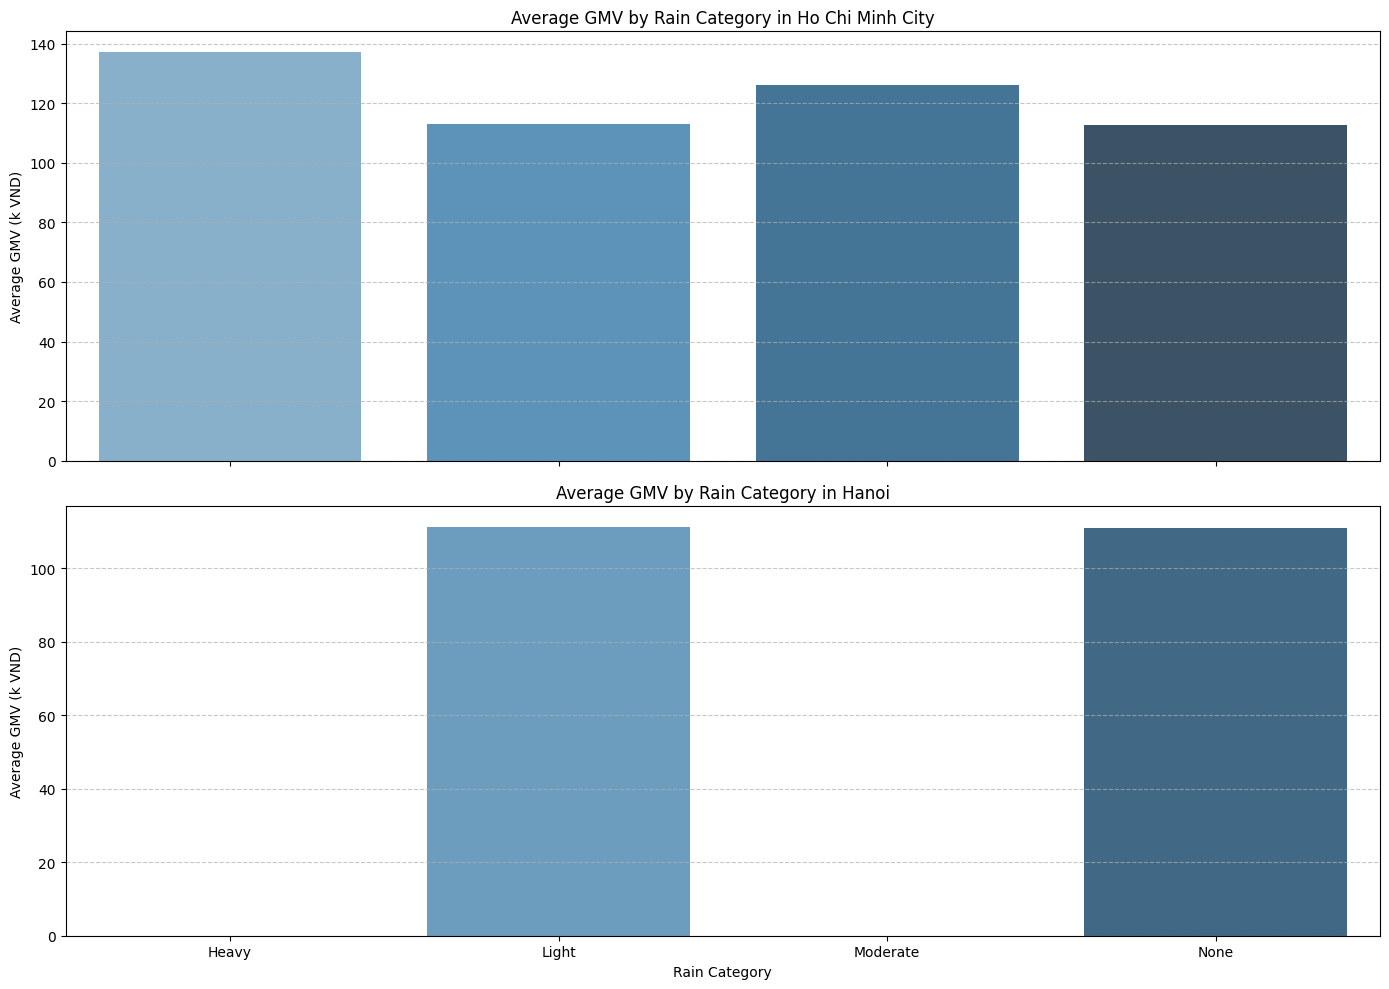

In [23]:
# Plotting Average GMV by Rain Category for each city
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

sns.barplot(data=rain_impact[rain_impact['city'] == 'Ho Chi Minh City'],
            x='rain_category', y='avg_gmv', ax=axes[0], palette='Blues_d', hue='rain_category', legend=False)
axes[0].set_title('Average GMV by Rain Category in Ho Chi Minh City')
axes[0].set_ylabel('Average GMV (k VND)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(data=rain_impact[rain_impact['city'] == 'Hanoi'],
            x='rain_category', y='avg_gmv', ax=axes[1], palette='Blues_d', hue='rain_category', legend=False)
axes[1].set_title('Average GMV by Rain Category in Hanoi')
axes[1].set_ylabel('Average GMV (k VND)')
axes[1].set_xlabel('Rain Category')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

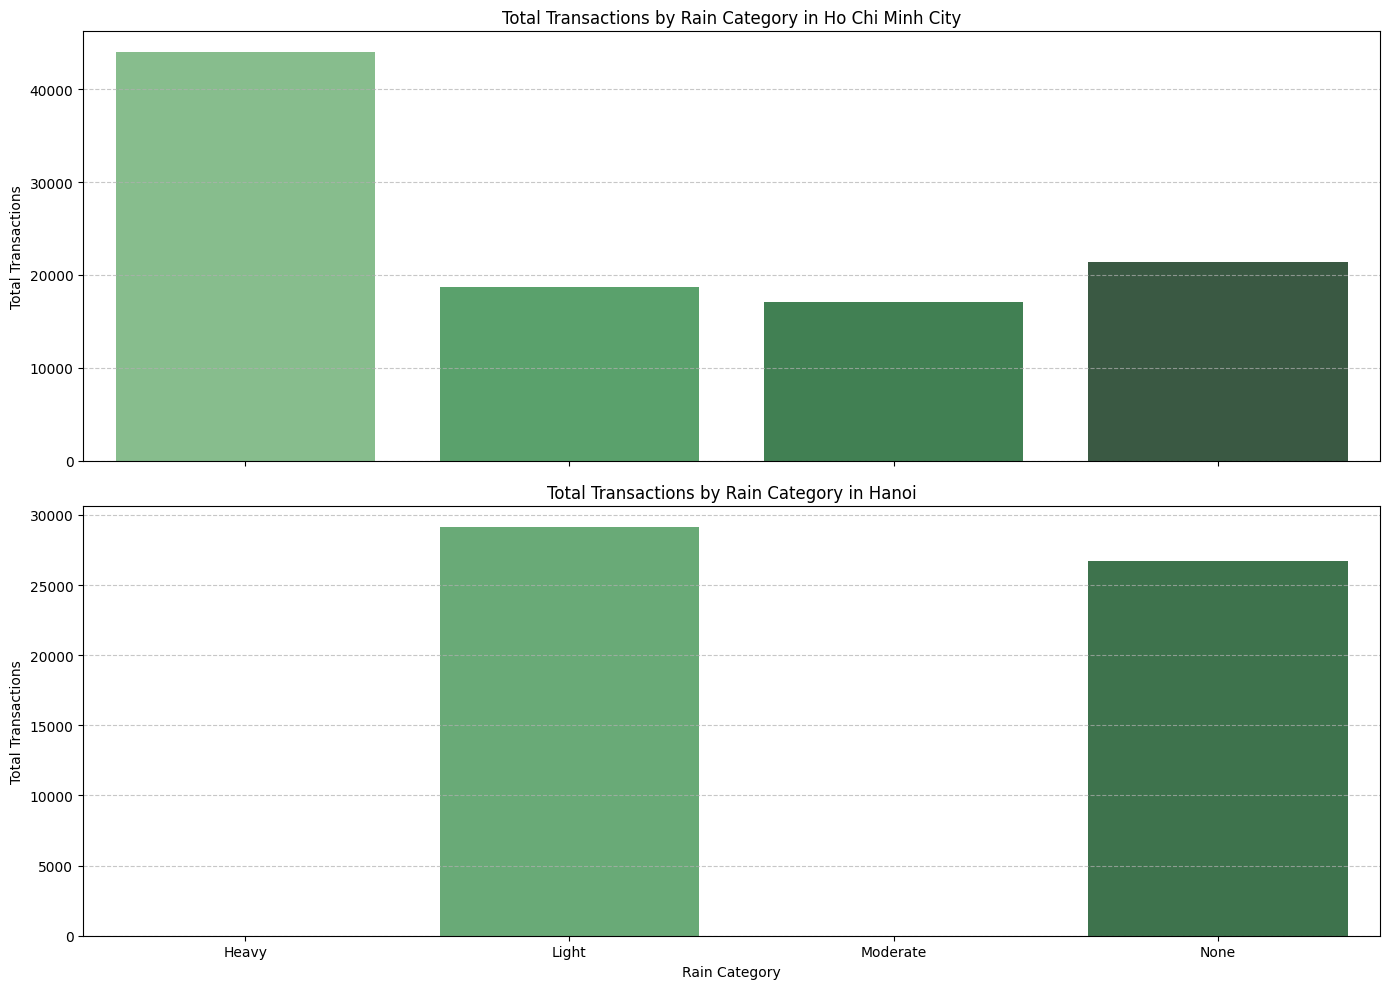

In [24]:
# Plotting Total Transactions by Rain Category for each city
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

sns.barplot(data=rain_impact[rain_impact['city'] == 'Ho Chi Minh City'],
            x='rain_category', y='total_transactions', ax=axes[0], palette='Greens_d', hue='rain_category', legend=False)
axes[0].set_title('Total Transactions by Rain Category in Ho Chi Minh City')
axes[0].set_ylabel('Total Transactions')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(data=rain_impact[rain_impact['city'] == 'Hanoi'],
            x='rain_category', y='total_transactions', ax=axes[1], palette='Greens_d', hue='rain_category', legend=False)
axes[1].set_title('Total Transactions by Rain Category in Hanoi')
axes[1].set_ylabel('Total Transactions')
axes[1].set_xlabel('Rain Category')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()